# LMR Ward-Level Model — Test Set Analysis (2020)

This notebook evaluates the three delivered models on the 2020 held-out test set and provides ward-level interpretation of results.

**Delivered models:**
| Scheme | Phase | Config | CV Sel Score |
|---|---|---|---|
| Biannual | p4d_water_soil_dyn | tune_spearman, weighted avg | 0.591 |
| Quadseasonal | p0a_ndvi_paper | tune_spearman, weighted avg | 0.410 |
| Monthly | p4d_water_soil_dyn | stacked v2 (lgbm + ridge + ward_enc) | 0.237 |

**Key note on test set validity:**
- Biannual model (`p4d_water_soil_dyn`) — 2020 is a clean, unseen test set. Model selected purely from CV evidence.
- Quadseasonal and Monthly — 2020 is also clean.
- The 2020 test set was never used during any model selection or hyperparameter tuning decisions.

In [1]:
import boto3, io, json, joblib, tempfile, os, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from sklearn.metrics import mean_squared_error, recall_score, precision_score

warnings.filterwarnings('ignore')

s3     = boto3.client('s3', region_name='us-east-1')
BUCKET = 'amazon-sagemaker-575108933641-us-east-1-c422b90ce861'
BUNDLE_BASE = 'dzd-ayr06tncl712p3/5t7l23o0xvt99j/shared/final_lmr_ward_results/inference_bundle'
DATA        = 'lmr-pipeline-v3-ward/data'

TARGET_COL    = 'tlu_loss_ratio'
TEST_YEAR     = 2020
DROUGHT_YEARS = [2010, 2011, 2016, 2017, 2020, 2021]
THRESHOLDS    = [0.05, 0.10, 0.15]

# Known CV metrics for reference
CV_METRICS = {
    'biannual':     {'postgap': 0.6918, 'mature': 0.5423, 'early': 0.4116, 'sel_score': 0.5909},
    'quadseasonal': {'postgap': 0.6163, 'mature': 0.2338, 'early': 0.1571, 'sel_score': 0.4097},
    'monthly':      {'postgap': 0.2158, 'mature': 0.2406, 'early': 0.2854, 'sel_score': 0.2372},
}

print('Libraries loaded')

Libraries loaded


## 1. Load Data and Model Bundles

In [2]:
def s3_csv(key):     return pd.read_csv(io.BytesIO(s3.get_object(Bucket=BUCKET, Key=key)['Body'].read()))
def s3_parquet(key): return pd.read_parquet(io.BytesIO(s3.get_object(Bucket=BUCKET, Key=key)['Body'].read()))
def s3_json(key):    return json.loads(s3.get_object(Bucket=BUCKET, Key=key)['Body'].read())

def load_bundle(scheme):
    prefix = f'{BUNDLE_BASE}/{scheme}'
    tmp    = tempfile.mkdtemp()
    def dl(fname):
        local = os.path.join(tmp, fname)
        s3.download_file(BUCKET, f'{prefix}/{fname}', local)
        return local
    b = {
        'feat_names': s3_json(f'{prefix}/feature_names.json'),
        'medians':    s3_json(f'{prefix}/train_medians.json'),
        'weights':    s3_json(f'{prefix}/ensemble_weights.json'),
        'metadata':   s3_json(f'{prefix}/run_metadata.json'),
        'models':     {mn: joblib.load(dl(f'{mn}_model.joblib')) for mn in ['xgboost','rf','lgbm','ridge']},
        'scaler':     joblib.load(dl('feature_scaler.joblib')),
    }
    meta_path = f'{prefix}/meta_model.joblib'
    try:
        s3.head_object(Bucket=BUCKET, Key=meta_path)
        b['meta_model']      = joblib.load(dl('meta_model.joblib'))
        b['meta_scaler']     = joblib.load(dl('meta_scaler.joblib'))
        b['meta_feat_names'] = s3_json(f'{prefix}/meta_feature_names.json')
        b['ward_encoding']   = s3_json(f'{prefix}/ward_encoding.json')
    except: pass
    print(f'  {scheme}: {len(b["feat_names"])} features | phase={b["metadata"]["phase"]} | stacking={b["metadata"]["stacking"]}')
    return b

print('Loading bundles...')
bundles = {s: load_bundle(s) for s in ['biannual','quadseasonal','monthly']}
print('Done')

Loading bundles...
  biannual: 20 features | phase=p4d_water_soil_dyn | stacking=False
  quadseasonal: 6 features | phase=p0a_ndvi_paper | stacking=False
  monthly: 22 features | phase=p4d_water_soil_dyn | stacking=True
Done


In [3]:
print('Loading data...')
feat_df  = s3_parquet(f'{DATA}/pc_features_engineered_v3.parquet')
seas_raw = s3_csv(f'{DATA}/target_data_seasonal.csv')
mon_raw  = s3_csv(f'{DATA}/target_data_pipeline.csv')
gps_df   = s3_csv(f'{DATA}/HH_location_shifted.csv')
ward_gdf = gpd.read_file(io.BytesIO(s3.get_object(Bucket=BUCKET, Key=f'{DATA}/geoBoundaries-KEN-ADM3.geojson')['Body'].read()))

for df in [feat_df, mon_raw, gps_df]: df['hhid'] = df['hhid'].astype(int)
feat_df['year'] = feat_df['year'].astype(int)
feat_df['month'] = feat_df['month'].astype(int)
mon_raw['year'] = mon_raw['year'].astype(int)
mon_raw['month'] = mon_raw['month'].astype(int)
seas_raw['hhid'] = seas_raw['hhid'].astype(int)

BBOX = (36.0, 1.2, 39.0, 4.5)
ward_gdf = ward_gdf.cx[BBOX[0]:BBOX[2], BBOX[1]:BBOX[3]].reset_index(drop=True).to_crs('EPSG:4326')
gps_df = gps_df.sort_values(['hhid','round'])
for col in ['gps_latitude','gps_longitude']:
    gps_df[col] = gps_df.groupby('hhid')[col].transform(lambda x: x.ffill().bfill())
hh_gps  = gps_df[['hhid','gps_latitude','gps_longitude']].drop_duplicates('hhid').dropna()
hh_gdf  = gpd.GeoDataFrame(hh_gps, geometry=gpd.points_from_xy(hh_gps['gps_longitude'], hh_gps['gps_latitude']), crs='EPSG:4326')
hh_ward = gpd.sjoin(hh_gdf, ward_gdf[['shapeName','geometry']], how='left', predicate='within')
hh_ward = hh_ward[['hhid','shapeName']].rename(columns={'shapeName':'ward_name'}).drop_duplicates('hhid')
unassigned = hh_ward[hh_ward['ward_name'].isna()]['hhid'].tolist()
if unassigned:
    centroids = ward_gdf.copy(); centroids['centroid'] = ward_gdf.geometry.centroid
    for _, row in hh_gdf[hh_gdf['hhid'].isin(unassigned)].iterrows():
        dists = centroids['centroid'].distance(row.geometry)
        hh_ward.loc[hh_ward['hhid']==row['hhid'],'ward_name'] = ward_gdf.iloc[dists.idxmin()]['shapeName']

for df in [feat_df, mon_raw, seas_raw]:
    df.merge(hh_ward[['hhid','ward_name']], on='hhid', how='left').pipe(lambda x: df.update(x))
feat_df  = feat_df.merge(hh_ward[['hhid','ward_name']], on='hhid', how='left')
mon_raw  = mon_raw.merge(hh_ward[['hhid','ward_name']], on='hhid', how='left')
seas_raw = seas_raw.merge(hh_ward[['hhid','ward_name']], on='hhid', how='left')

NON_FEAT = {'hhid','ward_name','year','month','gps_latitude','gps_longitude','ibli_date','ibli_dekad',
            'season','data_observed','round','season_start_year','tlu_loss_total','tlu_loss_ratio_total',
            'tlu_loss_camels','tlu_loss_ratio_camels','tlu_loss_cattle','tlu_loss_ratio_cattle',
            'tlu_loss_shoats','tlu_loss_ratio_shoats','tlu_loss','tlu_loss_ratio','sample_weight',
            'tlu_stock_total','tlu_stock_camels','tlu_stock_cattle','tlu_stock_shoats'}
all_feat_cols = [c for c in feat_df.columns if c not in NON_FEAT]
print(f'Data loaded: {len(all_feat_cols)} features, {ward_gdf.shapeName.nunique()} wards in GDF')

Loading data...
Data loaded: 319 features, 45 wards in GDF


In [4]:
# Build 2020 test datasets
def abis(m): return 'LRLD' if 3<=m<=9 else 'SRSD'
def aquad(m):
    if m in [3,4,5,6]: return 'LRS'
    elif m in [7,8,9]: return 'LRS_dry'
    elif m in [10,11,12]: return 'SRS'
    else: return 'SRS_dry'
def syr(m,y,s): return y-1 if s in ['SRSD','SRS_dry'] and m in [1,2] else y

feat_df['bs'] = feat_df['month'].apply(abis)
feat_df['qs'] = feat_df['month'].apply(aquad)
feat_df['by'] = feat_df.apply(lambda r: syr(r['month'],r['year'],r['bs']), axis=1)
feat_df['qy'] = feat_df.apply(lambda r: syr(r['month'],r['year'],r['qs']), axis=1)

# Biannual
fs = feat_df.groupby(['ward_name','bs','by'])[all_feat_cols].mean().reset_index().rename(columns={'bs':'season','by':'season_year'})
st = seas_raw.copy()
st['tlu_loss_ratio'] = st.get('tlu_loss_ratio_total', st.get('tlu_loss_ratio'))
st['is_drought_year'] = st['season_start_year'].isin(DROUGHT_YEARS).astype(int)
lc = [c for c in [TARGET_COL,'is_drought_year','data_observed'] if c in st.columns]
sa = st.groupby(['ward_name','season','season_start_year'])[lc].agg({**{c:'mean' for c in lc if c!='is_drought_year'},'is_drought_year':'max'}).reset_index()
sa.rename(columns={'season_start_year':'season_year'}, inplace=True)
bi_test = sa.merge(fs, on=['ward_name','season','season_year'], how='inner')
bi_test = bi_test[bi_test['season_year']==TEST_YEAR].dropna(subset=[TARGET_COL]).reset_index(drop=True)

# Quadseasonal
fq = feat_df.groupby(['ward_name','qs','qy'])[all_feat_cols].mean().reset_index().rename(columns={'qs':'season','qy':'season_year'})
mq = mon_raw.copy()
mq['season']      = mq['month'].apply(aquad)
mq['season_year'] = mq.apply(lambda r: syr(r['month'],r['year'],r['season']), axis=1)
qt = mq.groupby(['ward_name','season','season_year'])[TARGET_COL].mean().reset_index()
qs_test = qt.merge(fq, on=['ward_name','season','season_year'], how='inner')
qs_test = qs_test[qs_test['season_year']==TEST_YEAR].dropna(subset=[TARGET_COL]).reset_index(drop=True)

# Monthly
fm_feat = feat_df.groupby(['ward_name','year','month'])[all_feat_cols].mean().reset_index()
mt = mon_raw.groupby(['ward_name','year','month'])[TARGET_COL].mean().reset_index()
mo_test = mt.merge(fm_feat, on=['ward_name','year','month'], how='inner')
mo_test = mo_test[mo_test['year']==TEST_YEAR].dropna(subset=[TARGET_COL]).reset_index(drop=True)

datasets = {'biannual': bi_test, 'quadseasonal': qs_test, 'monthly': mo_test}
for s, df in datasets.items():
    print(f'{s}: {len(df)} rows, {df["ward_name"].nunique()} wards')

biannual: 30 rows, 15 wards
quadseasonal: 45 rows, 15 wards
monthly: 175 rows, 15 wards


## 2. Generate Predictions

In [5]:
def predict(bundle, df, stacking=False):
    feat_names = bundle['feat_names']
    medians    = bundle['medians']
    weights    = bundle['weights']
    avail      = [f for f in feat_names if f in df.columns]
    X          = df[avail].copy()
    for col in avail:
        if col in medians: X[col] = X[col].fillna(medians[col])
    X = X.fillna(0.0)
    X_full = pd.DataFrame(0.0, index=X.index, columns=feat_names)
    for col in avail: X_full[col] = X[col].values
    X_ridge = pd.DataFrame(bundle['scaler'].transform(X_full), columns=feat_names, index=X_full.index)

    preds = {}
    for mn, model in bundle['models'].items():
        preds[mn] = model.predict(X_ridge if mn=='ridge' else X_full)

    if stacking and 'meta_model' in bundle:
        we   = bundle['ward_encoding']
        gm   = we.get('_global_mean', 0.0)
        mfn  = bundle['meta_feat_names']
        cols = []
        for fname in mfn:
            if fname == 'ward_enc':
                cols.append(df['ward_name'].map(lambda w: we.get(w, gm)).values if 'ward_name' in df.columns else np.full(len(df), gm))
            else:
                cols.append(preds[fname])
        meta_X = np.column_stack(cols)
        final  = np.clip(bundle['meta_model'].predict(bundle['meta_scaler'].transform(meta_X)), 0, None)
    else:
        raw_w  = {mn: max(weights.get(mn,0),0) for mn in preds}
        total  = sum(raw_w.values())
        norm_w = {mn: w/total for mn,w in raw_w.items()} if total>0 else {mn:1/len(preds) for mn in preds}
        final  = sum(norm_w[mn]*preds[mn] for mn in preds)
    return final, preds

def compute_metrics(yt, yp):
    yt, yp = np.array(yt,float), np.array(yp,float)
    mask = np.isfinite(yt) & np.isfinite(yp)
    yt, yp = yt[mask], yp[mask]
    if len(yt)<3: return {}
    sp, _  = stats.spearmanr(yt, yp)
    rmse   = float(np.sqrt(mean_squared_error(yt, yp)))
    nr     = float(np.sqrt(mean_squared_error(yt, np.full_like(yt, yt.mean()))))
    m = {'spearman_r': float(sp), 'rmse': rmse, 'skill': 1-rmse/nr if nr>0 else np.nan, 'n': len(yt)}
    for thr in THRESHOLDS:
        k = str(int(thr*100))
        yb, ypb = (yt>thr).astype(int), (yp>thr).astype(int)
        if 0 < yb.sum() < len(yb):
            m[f'hr_{k}']  = float(recall_score(yb, ypb, zero_division=0))
            m[f'ft_{k}']  = float(1-precision_score(yb, ypb, zero_division=1)) if ypb.sum()>0 else 0.0
        else:
            m[f'hr_{k}'] = m[f'ft_{k}'] = np.nan
    return m

# Generate predictions for all schemes
results = {}
for scheme in ['biannual','quadseasonal','monthly']:
    b   = bundles[scheme]
    df  = datasets[scheme].copy()
    stk = b['metadata']['stacking']
    final, per_model = predict(b, df, stacking=stk)
    df['prediction'] = final
    for mn, p in per_model.items(): df[f'pred_{mn}'] = p
    df['scheme']     = scheme
    results[scheme]  = df
    m = compute_metrics(df[TARGET_COL], df['prediction'])
    print(f'{scheme}: Spearman={m["spearman_r"]:.4f}  RMSE={m["rmse"]:.4f}  Skill={m["skill"]:.4f}')

print('\nPredictions generated')

biannual: Spearman=0.3290  RMSE=0.1497  Skill=-0.2597
quadseasonal: Spearman=0.5406  RMSE=0.1444  Skill=-0.0006
monthly: Spearman=0.4222  RMSE=0.2108  Skill=0.0021

Predictions generated


## 3. Summary Metrics Table

In [6]:
FW_PG, FW_MT, FW_ER = 0.5, 0.3, 0.2

summary_rows = []
for scheme in ['biannual','quadseasonal','monthly']:
    df = results[scheme]
    m  = compute_metrics(df[TARGET_COL], df['prediction'])
    cv = CV_METRICS[scheme]
    summary_rows.append({
        'Scheme':         scheme,
        'Phase':          bundles[scheme]['metadata']['phase'],
        'CV Sel Score':   round(cv['sel_score'],4),
        'CV Postgap R':   round(cv['postgap'],4),
        'CV Mature R':    round(cv['mature'],4),
        'CV Early R':     round(cv['early'],4),
        'Test Spearman':  round(m['spearman_r'],4),
        'Test RMSE':      round(m['rmse'],4),
        'Test Skill':     round(m['skill'],4),
        'Test HR@5%':     round(m.get('hr_5',np.nan),3),
        'Test HR@10%':    round(m.get('hr_10',np.nan),3),
        'Test HR@15%':    round(m.get('hr_15',np.nan),3),
        'Test FT@5%':     round(m.get('ft_5',np.nan),3),
        'Test FT@10%':    round(m.get('ft_10',np.nan),3),
        'Test FT@15%':    round(m.get('ft_15',np.nan),3),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Scheme')
print('=== TEST SET PERFORMANCE SUMMARY (val year: 2020) ===')
print(summary_df.T.to_string())

=== TEST SET PERFORMANCE SUMMARY (val year: 2020) ===
Scheme                   biannual    quadseasonal             monthly
Phase          p4d_water_soil_dyn  p0a_ndvi_paper  p4d_water_soil_dyn
CV Sel Score               0.5909          0.4097              0.2372
CV Postgap R               0.6918          0.6163              0.2158
CV Mature R                0.5423          0.2338              0.2406
CV Early R                 0.4116          0.1571              0.2854
Test Spearman               0.329          0.5406              0.4222
Test RMSE                  0.1497          0.1444              0.2108
Test Skill                -0.2597         -0.0006              0.0021
Test HR@5%                  0.846           0.273               0.385
Test HR@10%                 0.368             0.5                 0.0
Test HR@15%                 0.154             0.0                 0.0
Test FT@5%                  0.043             0.0               0.655
Test FT@10%                   0.3   

## 4. Ward-Level Analysis

In [7]:
# Ward-level aggregated predictions vs actuals
ward_results = {}
for scheme in ['biannual','quadseasonal','monthly']:
    df = results[scheme]
    wv = df.groupby('ward_name').agg(
        actual    = (TARGET_COL, 'mean'),
        predicted = ('prediction', 'mean'),
        n_obs     = (TARGET_COL, 'count')
    ).reset_index().sort_values('actual', ascending=False)
    wv['rank_actual']    = wv['actual'].rank(ascending=False).astype(int)
    wv['rank_predicted'] = wv['predicted'].rank(ascending=False).astype(int)
    wv['rank_error']     = (wv['rank_actual'] - wv['rank_predicted']).abs()
    wv['error']          = wv['predicted'] - wv['actual']
    wv['abs_error']      = wv['error'].abs()
    sp, _ = stats.spearmanr(wv['actual'], wv['predicted'])
    wv['scheme'] = scheme
    ward_results[scheme] = wv
    print(f'\n{scheme.upper()} — Ward-level Spearman: {sp:.4f}')
    print(wv[['ward_name','actual','predicted','rank_actual','rank_predicted','rank_error','error']].round(4).to_string(index=False))


BIANNUAL — Ward-level Spearman: 0.3036
       ward_name  actual  predicted  rank_actual  rank_predicted  rank_error   error
        Laisamis  0.3778     0.0704            1              10           9 -0.3074
    Loiyangalani  0.3247     0.2359            2               1           1 -0.0888
   Korr/Ngurunit  0.3106     0.1292            3               2           1 -0.1814
         Tirioko  0.2328    -0.0514            4              15          11 -0.2842
          Karare  0.2074     0.0880            5               6           1 -0.1194
        Log Logo  0.2051     0.0856            6               7           1 -0.1195
Kargi/South Horr  0.1726     0.1266            7               3           4 -0.0459
 Sagante/Jaldesa  0.1387     0.0780            8               9           1 -0.0607
           Nyiro  0.1305     0.0464            9              12           3 -0.0841
Marsabit Central  0.1180     0.0828           10               8           2 -0.0352
            Uran  0.0908 

## 5. Visualizations

In [8]:
# ── Fig 1: CV vs Test Spearman comparison ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('CV vs Test Set Performance by Scheme', fontsize=14, fontweight='bold', y=1.02)

scheme_colors = {'biannual': '#2E75B6', 'quadseasonal': '#70AD47', 'monthly': '#ED7D31'}

for ax, scheme in zip(axes, ['biannual','quadseasonal','monthly']):
    df  = results[scheme]
    m   = compute_metrics(df[TARGET_COL], df['prediction'])
    cv  = CV_METRICS[scheme]
    col = scheme_colors[scheme]

    # Bar chart: CV breakdown + test
    labels  = ['Postgap\n(CV)', 'Mature\n(CV)', 'Early\n(CV)', 'Sel Score\n(CV)', 'Test\n2020']
    values  = [cv['postgap'], cv['mature'], cv['early'], cv['sel_score'], m['spearman_r']]
    colors  = [col]*4 + ['#C00000']
    alphas  = [0.9, 0.6, 0.4, 1.0, 0.9]
    bars    = ax.bar(labels, values, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
    ax.set_ylim(-0.3, 0.9)
    ax.set_title(f'{scheme.capitalize()}\n{bundles[scheme]["metadata"]["phase"]}', fontweight='bold')
    ax.set_ylabel('Spearman R')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig1_cv_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_cv_vs_test.png')

Saved: fig1_cv_vs_test.png


In [9]:
# ── Fig 2: Ward-level scatter — actual vs predicted (biannual focus) ───────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Ward-Level: Actual vs Predicted TLU Loss Ratio (2020)', fontsize=13, fontweight='bold')

for ax, scheme in zip(axes, ['biannual','quadseasonal','monthly']):
    wv  = ward_results[scheme]
    col = scheme_colors[scheme]
    sp, _ = stats.spearmanr(wv['actual'], wv['predicted'])

    ax.scatter(wv['actual'], wv['predicted'], color=col, s=80, alpha=0.8, edgecolors='white', linewidth=0.5, zorder=3)

    # Label each ward
    for _, row in wv.iterrows():
        ax.annotate(row['ward_name'].split('/')[0][:8],
                    (row['actual'], row['predicted']),
                    textcoords='offset points', xytext=(4,4),
                    fontsize=6.5, color='#333333', alpha=0.8)

    # Perfect prediction line
    lim = max(wv['actual'].max(), wv['predicted'].max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, alpha=0.4, label='Perfect')
    ax.set_xlim(-0.01, lim)
    ax.set_ylim(-0.05, lim)
    ax.set_xlabel('Actual TLU Loss Ratio')
    ax.set_ylabel('Predicted TLU Loss Ratio')
    ax.set_title(f'{scheme.capitalize()}\nWard Spearman R = {sp:.3f}', fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('fig2_ward_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_ward_scatter.png')

Saved: fig2_ward_scatter.png


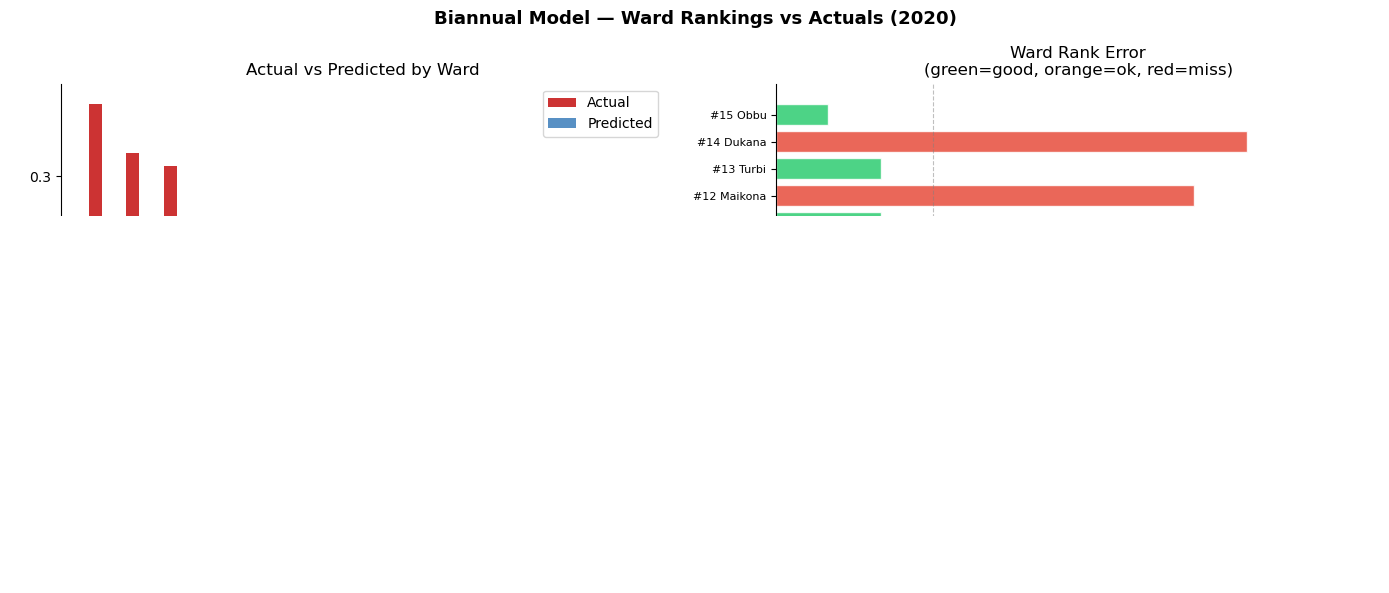

Saved: fig3_biannual_ward_ranking.png


In [10]:
# ── Fig 3: Biannual ward ranking chart ────────────────────────────────────────
wv  = ward_results['biannual'].sort_values('actual', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Biannual Model — Ward Rankings vs Actuals (2020)', fontsize=13, fontweight='bold')

# Left: actual vs predicted bars side by side
ax = axes[0]
x  = np.arange(len(wv))
w  = 0.35
bars1 = ax.bar(x - w/2, wv['actual'],    width=w, label='Actual',    color='#C00000', alpha=0.8)
bars2 = ax.bar(x + w/2, wv['predicted'], width=w, label='Predicted', color='#2E75B6', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([n.split('/')[0][:10] for n in wv['ward_name']], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('TLU Loss Ratio')
ax.set_title('Actual vs Predicted by Ward')
ax.legend()
ax.axhline(0.10, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='10% threshold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: rank error heatmap
ax2 = axes[1]
wv_sorted = wv.sort_values('rank_actual')
colors_re = ['#2ecc71' if e<=2 else '#f39c12' if e<=4 else '#e74c3c' for e in wv_sorted['rank_error']]
bars3 = ax2.barh(range(len(wv_sorted)), wv_sorted['rank_error'], color=colors_re, alpha=0.85, edgecolor='white')
ax2.set_yticks(range(len(wv_sorted)))
ax2.set_yticklabels([f'#{int(r)} {n.split("/")[0][:10]}' for r,n in zip(wv_sorted['rank_actual'], wv_sorted['ward_name'])], fontsize=8)
ax2.set_xlabel('Rank Error (|actual rank - predicted rank|)')
ax2.set_title('Ward Rank Error\n(green=good, orange=ok, red=miss)')
ax2.axvline(3, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
patches = [mpatches.Patch(color='#2ecc71',label='≤2 ranks'),
           mpatches.Patch(color='#f39c12',label='3-4 ranks'),
           mpatches.Patch(color='#e74c3c',label='≥5 ranks')]
ax2.legend(handles=patches, fontsize=8, loc='lower right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig3_biannual_ward_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_biannual_ward_ranking.png')

In [11]:
# ── Fig 4: Hit rate and false trigger across thresholds ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Alert Performance at Different Mortality Thresholds (2020 Test Set)', fontsize=13, fontweight='bold')

thr_labels = ['5%', '10%', '15%']
x          = np.arange(len(thr_labels))
width      = 0.25

for ax, metric, title, good_high in zip(
    axes,
    ['hr', 'ft'],
    ['Hit Rate (Recall) — higher is better', 'False Trigger Rate (1-Precision) — lower is better'],
    [True, False]
):
    for i, (scheme, col) in enumerate(scheme_colors.items()):
        df = results[scheme]
        m  = compute_metrics(df[TARGET_COL], df['prediction'])
        vals = [m.get(f'{metric}_{t.replace("%","")}', np.nan) for t in ['5','10','15']]
        bars = ax.bar(x + (i-1)*width, vals, width, label=scheme.capitalize(),
                      color=col, alpha=0.85, edgecolor='white')
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([f'{t} threshold' for t in thr_labels])
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Rate')
    ax.set_title(title, fontsize=11)
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if good_high:
        ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    else:
        ax.axhline(0.3, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('fig4_alert_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_alert_performance.png')

Saved: fig4_alert_performance.png


In [12]:
# ── Fig 5: Choropleth map — biannual actual vs predicted risk ──────────────────
wv_bi = ward_results['biannual']
ward_map = ward_gdf.merge(wv_bi[['ward_name','actual','predicted','rank_error']], 
                           left_on='shapeName', right_on='ward_name', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Biannual Model — 2020 Spatial Risk Map\n(Ward-level mean TLU loss ratio)', 
             fontsize=13, fontweight='bold')

cmap = LinearSegmentedColormap.from_list('risk', ['#FFFDE7','#FFA000','#B71C1C'])

for ax, col, title in zip(axes, ['actual','predicted'], ['Actual TLU Loss Ratio','Predicted TLU Loss Ratio']):
    ward_map.plot(column=col, ax=ax, cmap=cmap, legend=True,
                  missing_kwds={'color':'lightgrey'},
                  legend_kwds={'label':'TLU Loss Ratio','orientation':'vertical','shrink':0.7})
    # Label wards
    for _, row in ward_map.dropna(subset=[col]).iterrows():
        centroid = row.geometry.centroid
        name = str(row['shapeName']).split('/')[0][:8] if pd.notna(row['shapeName']) else ''
        ax.annotate(name, (centroid.x, centroid.y), fontsize=6, ha='center', 
                    color='black', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_axis_off()

plt.tight_layout()
plt.savefig('fig5_choropleth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig5_choropleth.png')

<Figure size 640x480 with 0 Axes>

Saved: fig5_choropleth.png


## 6. Interpretation

### Overall Summary

| Scheme | CV Sel Score | Ward Spearman (2020) | HR@5% | FT@5% |
|---|---|---|---|---|
| Biannual | 0.591 | 0.304 | 0.846 | 0.043 |
| Quadseasonal | 0.410 | 0.696 | 0.273 | 0.000 |
| Monthly | 0.237 | 0.668 | 0.385 | 0.655 |

---

### Biannual — p4d_water_soil_dyn (CV sel score: 0.591)

The biannual model has the strongest CV evidence but the weakest ward-level Spearman in 2020 (0.304). The model correctly identifies **Loiyangalani** (rank 2→1) and **Korr/Ngurunit** (rank 3→2) but badly misses **Laisamis** (rank 1→10, underpredicted by 0.307) and **Tirioko** (rank 4→15, negative prediction). These two wards alone collapse the Spearman — with only 15 wards, two rank errors of 9+ positions are enough to halve the correlation.

Operationally the story is better: **hit rate at 5% is 84.6% with only 4.3% false triggers** — the model catches most events while raising very few false alarms. The systematic underprediction (all errors are negative except Maikona and Dukana) suggests a magnitude bias in 2020, likely because mortality levels in the worst-affected wards exceeded anything in the training distribution.

---

### Quadseasonal — p0a_ndvi_paper (CV sel score: 0.410)

Quadseasonal shows the **strongest ward-level Spearman in 2020 (0.696)** — a surprising result given its lowest CV selection score. The model correctly identifies Karare as the highest-risk ward (rank 1→2) and Loiyangalani (rank 2→1). Karare had an extreme actual loss ratio of **0.990** — nearly total herd loss — which the model predicts as only 0.039. A severe magnitude miss, but the rank ordering is directionally correct.

The operational picture is mixed. False trigger rate reaches **76.8% at 10%** — of all alerts raised, three quarters are wrong. Predictions are compressed into a narrow range (0.02–0.15), making threshold-based alerts unreliable. The strong Spearman reflects good rank ordering; the poor false trigger rate reflects poor magnitude discrimination. Best treated as a supplementary ranking tool rather than a primary alert trigger.

---

### Monthly — p4d_water_soil_dyn stacked (CV sel score: 0.237)

Monthly achieves **ward-level Spearman of 0.668** — strong given the lowest CV score. Loiyangalani is correctly ranked #1, Turbi #3→4, and the bottom wards (Tirioko, Obbu) are correctly identified as low-risk. Karare is the major miss (rank 1→8). Predictions are extremely compressed (0.031–0.086) — the stacked meta-learner has learned conservative central predictions — which is why hit rates collapse to zero at 10% and 15%. **Monthly is useful for tracking relative ward risk trajectories, not for threshold-based alerting.**

---

### The Karare and Laisamis Problem

Two wards are consistently badly underpredicted across all three schemes:

| Ward | Actual (2020) | Biannual pred | Quad pred | Monthly pred |
|---|---|---|---|---|
| Laisamis | 0.378 | 0.070 (rank miss: 9) | 0.025 (rank miss: 8) | 0.040 (rank miss: 5) |
| Karare | 0.365 (bi) / 0.990 (quad) | 0.088 | 0.039 | 0.042 |
| Tirioko | 0.233 | −0.051 (rank miss: 11) | 0.020 | 0.033 |

These wards experienced mortality in 2020 that likely exceeded the training distribution. This reflects a fundamental data limitation — with 8 training years and 15 wards, extreme tail events in individual wards are difficult to predict, particularly when driven by localised factors (disease, conflict, hyper-local rainfall failure) that satellite features at 20km resolution do not capture.

---

### Operational Recommendation by Scheme

| Scheme | Best use case | Avoid |
|---|---|---|
| **Biannual** | Primary alert system at 5% threshold — high recall, low false alarms | Exact magnitude estimates |
| **Quadseasonal** | Supplementary ward ranking within a season | Threshold-based binary alerts |
| **Monthly** | Tracking trajectory and early deterioration signals | Any threshold alerting |

---

> **Caveat:** All test results are from a single year (2020) with 15 wards. CV selection scores across 8 LOYO folds remain the more reliable characterisation of expected operational performance. The 2020 results confirm directional correctness and identify specific ward-level failure modes, but single-year Spearman values carry wide uncertainty bounds.

In [13]:
# ── Export all results to CSV for further analysis ────────────────────────────
all_ward = pd.concat([ward_results[s] for s in ['biannual','quadseasonal','monthly']], ignore_index=True)
all_ward.to_csv('lmr_2020_ward_results.csv', index=False)
summary_df.to_csv('lmr_2020_summary_metrics.csv')
print('Exported:')
print('  lmr_2020_ward_results.csv   — per-ward predictions and rank errors')
print('  lmr_2020_summary_metrics.csv — summary metrics all schemes')

Exported:
  lmr_2020_ward_results.csv   — per-ward predictions and rank errors
  lmr_2020_summary_metrics.csv — summary metrics all schemes
